# Chick count comparison 

Creating a new clean file, using the 
- dfHuddleMLR_export_combined_uncertainty #Michelle's 2024 data
- dfHuddle_export_combined_uncertainty #Our circumpolar 2025 data

## These data were calculated in the manual_phenology_BP notebook 



Datasets to recreate the chick comparison figures and run model validation analyses on chicks vs breeding pair estimates 





In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful


In [9]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

dfRFD = pd.read_excel(os.path.join(INPUTPATH, "Final results/dfHuddle_export_combined_uncertainty.xlsx")) 
dfMLR = pd.read_excel(os.path.join(INPUTPATH, "Final results/dfHuddleMLR_export_combined_uncertainty.xlsx"))

#These data files already find the average number of breeding pairs and calculate uncertainty based on the two sources of error. 

#We then want to compare those data to chick counts and create figures

# Load chick count data
chick_counts = pd.read_excel(os.path.join(INPUTPATH, "Final data files/EP_Chick_counts.xlsx"))
chick_counts["count"] = pd.to_numeric(chick_counts["count"], errors="coerce")
chick_counts["date"]  = pd.to_datetime(chick_counts["date"], errors="coerce")
chick_counts["DOY"]   = chick_counts["date"].dt.dayofyear

# Filter to 2024 and 2025 spring chick counts
chick_clean = (
    chick_counts[
        (chick_counts["season"] == "spring") &
        (chick_counts["year"].isin([2024, 2025])) &
        (chick_counts["age"].str.strip() == "chicks") &
        chick_counts["count"].notna()
    ]
    .groupby(["colony", "date", "DOY", "year"], as_index=False)
    .agg(count_total=("count", "sum"))
    .rename(columns={"colony": "colony_name"})
)

print(f"Chick counts loaded: {len(chick_clean)} rows")
print(chick_clean[["colony_name", "year", "date", "count_total"]])

Chick counts loaded: 12 rows
   colony_name  year       date  count_total
0       Amanda  2025 2025-11-28      10387.0
1       Astrid  2025 2025-10-20       6258.0
2      Coulman  2024 2024-11-21      21242.0
3      Coulman  2025 2025-12-06       6686.0
4      Crozier  2024 2024-11-21       2773.0
5      Crozier  2025 2025-11-22       2782.0
6      Lazarev  2025 2025-12-17        800.0
7        Roget  2024 2024-11-21       7397.0
8        Roget  2025 2025-11-13       7736.0
9       Taylor  2025 2025-11-21       1987.0
10  Washington  2024 2024-11-15      13803.0
11  Washington  2025 2025-11-09      14297.0


MATCHED: colony=Amanda, year=2025, count_mean=9282, combined_se=1111
MATCHED: colony=Astrid, year=2025, count_mean=6253, combined_se=682
MATCHED: colony=Coulman, year=2024, count_mean=16376, combined_se=2391
MATCHED: colony=Coulman, year=2025, count_mean=16088, combined_se=2521
MATCHED: colony=Crozier, year=2024, count_mean=2350, combined_se=538
MATCHED: colony=Crozier, year=2025, count_mean=1991, combined_se=313
NO MATCH: colony=Lazarev, year=2025
MATCHED: colony=Roget, year=2024, count_mean=5261, combined_se=939
MATCHED: colony=Roget, year=2025, count_mean=7252, combined_se=1096
MATCHED: colony=Taylor, year=2025, count_mean=2470, combined_se=372
MATCHED: colony=Washington, year=2024, count_mean=10341, combined_se=1897
MATCHED: colony=Washington, year=2025, count_mean=11368, combined_se=1819

Rows matched: 11
    colony  year  BP_winter  combined_se_pm  chicks_obs  pct_diff
    Amanda  2025    9282.07         1111.06     10387.0     -10.6
    Astrid  2025    6253.03          681.75   

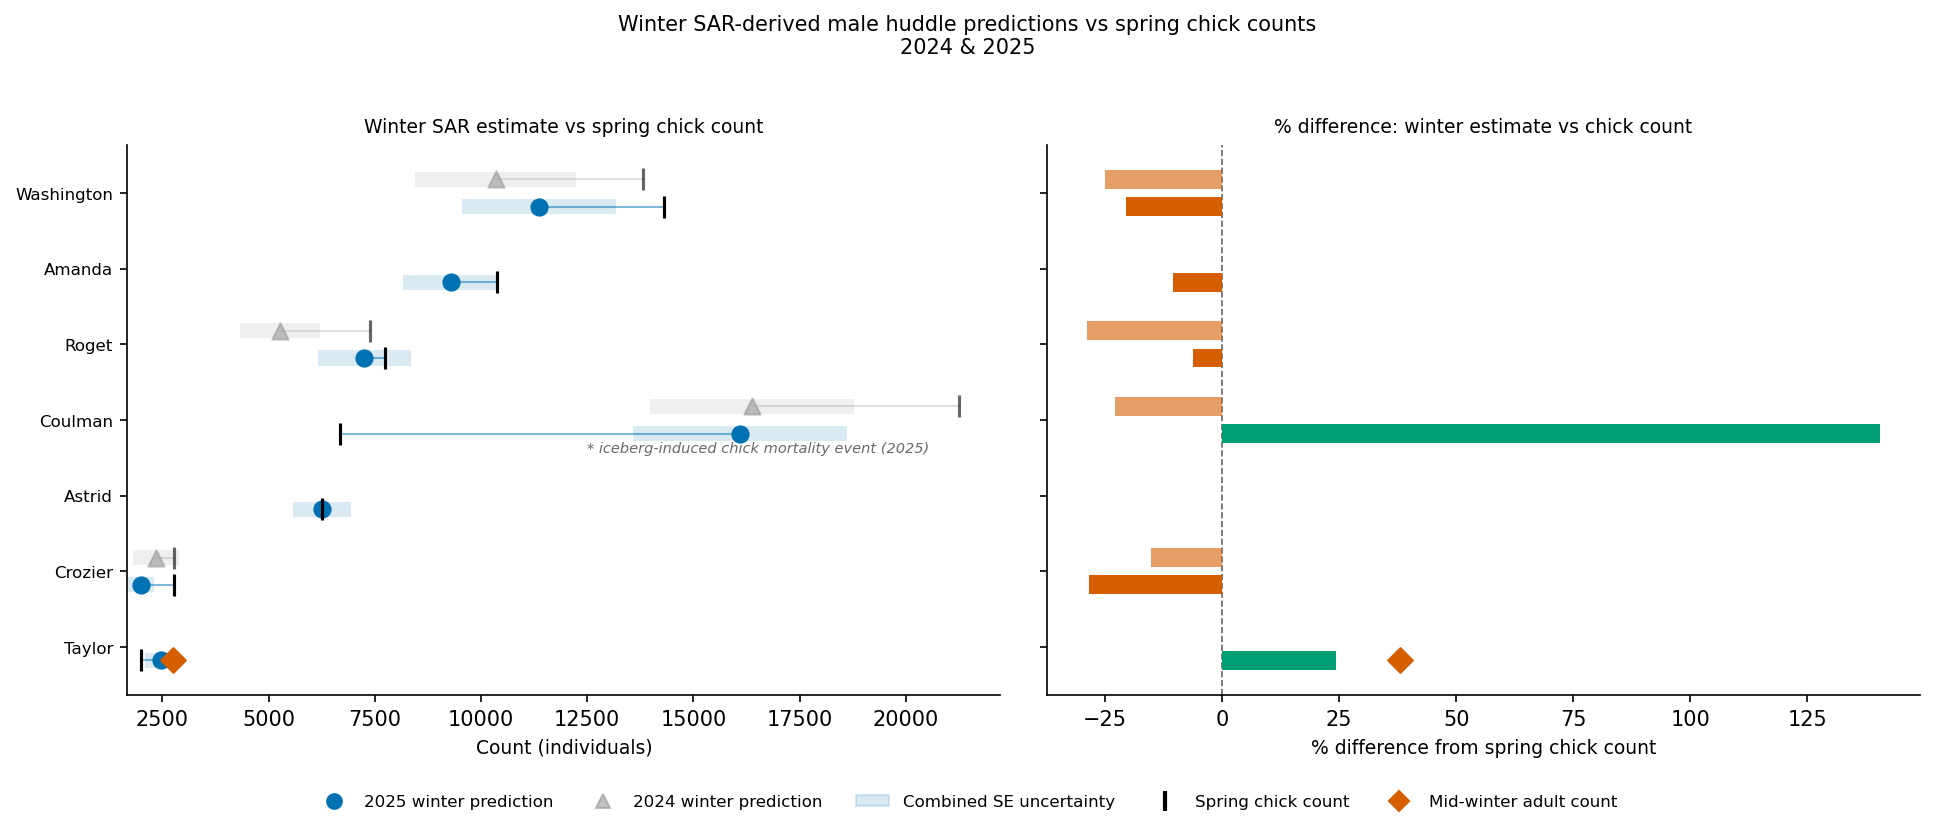


Winter vs spring chick count summary (2024 & 2025):
Colony                 Year    BP_winter      ±SE   chicks_obs   pct_diff flag
--------------------------------------------------------------------------------
Taylor                 2025        2,470      372        1,987      24.3%  low n
Crozier                2024        2,350      538        2,773     -15.3%  good
Crozier                2025        1,991      313        2,782     -28.4%  good
Astrid                 2025        6,253      682        6,258      -0.1%  low n
Coulman                2025       16,088    2,521        6,686     140.6%  good
Roget                  2024        5,261      939        7,397     -28.9%  good
Roget                  2025        7,252    1,096        7,736      -6.3%  good
Amanda                 2025        9,282    1,111       10,387     -10.6%  low n
Washington             2024       10,341    1,897       13,803     -25.1%  good
Washington             2025       11,368    1,819       14,297  

In [10]:
# ── Build comparison using combined uncertainty export dataframes ───────────
chick_clean["year"] = chick_clean["year"].astype(int)

comparison_rows = []

for _, row in chick_clean.iterrows():
    colony     = row["colony_name"]
    chicks_obs = row["count_total"]
    chick_year = row["year"]

    # Select correct combined uncertainty export dataframe
    if chick_year == 2025:
        df_huddle = dfRFD
    else:
        df_huddle = dfMLR

    # Match colony
    match = df_huddle[df_huddle["colony_name"] == colony]

    if len(match) == 0:
        print(f"NO MATCH: colony={colony}, year={chick_year}")
        continue

    r_huddle = match.iloc[0]
    print(f"MATCHED: colony={colony}, year={chick_year}, "
          f"count_mean={r_huddle['count_mean']:.0f}, "
          f"combined_se={r_huddle['combined_se_pm']:.0f}")

    comparison_rows.append({
        "colony":         colony,
        "year":           chick_year,
        "BP_winter":      r_huddle["count_mean"],
        "BP_lower":       r_huddle["combined_lower"],
        "BP_upper":       r_huddle["combined_upper"],
        "combined_se_pm": r_huddle["combined_se_pm"],
        "coeff_se_pm":    r_huddle["coeff_se_pm"],
        "obs_sem":        r_huddle["obs_sem"],
        "n_obs":          r_huddle["n_obs"],
        "uncertainty_flag": r_huddle["uncertainty_flag"],
        "chicks_obs":     chicks_obs,
    })

dfComp = pd.DataFrame(comparison_rows).dropna(subset=["BP_winter"])
dfComp["pct_diff"] = ((dfComp["BP_winter"] - dfComp["chicks_obs"]) /
                       dfComp["chicks_obs"] * 100).round(1)

print(f"\nRows matched: {len(dfComp)}")
print(dfComp[["colony", "year", "BP_winter", "combined_se_pm",
              "chicks_obs", "pct_diff"]].to_string(index=False))

# Sort by 2025 chick count for consistent y ordering
colony_order = (
    dfComp[dfComp["year"] == 2025]
    .sort_values("chicks_obs")["colony"]
    .tolist()
)
for c in dfComp[dfComp["year"] == 2024]["colony"].unique():
    if c not in colony_order:
        colony_order.append(c)

y_positions = {colony: i for i, colony in enumerate(colony_order)}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

year_colors  = {2024: "#999999", 2025: "#0072B2"}
year_alphas  = {2024: 0.6,       2025: 1.0}
year_markers = {2024: "^",       2025: "o"}

for _, r in dfComp.iterrows():
    if r["colony"] not in y_positions:
        continue

    y      = y_positions[r["colony"]]
    y_off  = y + (0.18 if r["year"] == 2024 else -0.18)
    color  = year_colors[r["year"]]
    alpha  = year_alphas[r["year"]]
    marker = year_markers[r["year"]]

    # Left panel
    ax = axes[0]
    # Combined uncertainty bar
    ax.barh(y_off, r["BP_upper"] - r["BP_lower"],
            left=r["BP_lower"],
            height=0.2, color=color, alpha=0.15, zorder=2)
    ax.scatter(r["BP_winter"], y_off,
               color=color, marker=marker, s=60,
               alpha=alpha, zorder=4)
    ax.scatter(r["chicks_obs"], y_off,
               color="black", marker="|", s=120,
               alpha=alpha, zorder=5)
    ax.plot([r["BP_winter"], r["chicks_obs"]], [y_off, y_off],
            color=color, linewidth=1.0, alpha=alpha * 0.5, zorder=3)

    # Right panel
    bar_color = "#009E73" if r["pct_diff"] >= 0 else "#D55E00"
    axes[1].barh(y_off, r["pct_diff"],
                 height=0.25, color=bar_color,
                 alpha=alpha, zorder=3)

axes[0].set_xlabel("Count (individuals)", fontsize=9)
axes[0].set_title("Winter SAR estimate vs spring chick count", fontsize=9)

axes[1].set_xlabel("% difference from spring chick count"
                   , fontsize=9)
axes[1].set_title("% difference: winter estimate vs chick count", fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ── Taylor ground truth ────────────────────────────────────────────────────
taylor_winter_adults = 2743
if "Taylor" in y_positions:
    y_taylor     = y_positions["Taylor"]
    y_taylor_off = y_taylor - 0.18

    axes[0].scatter(taylor_winter_adults, y_taylor_off,
                    color="#D55E00", marker="D", s=70, zorder=5)
    taylor_chicks = chick_clean.loc[
        (chick_clean["colony_name"] == "Taylor") &
        (chick_clean["year"] == 2025), "count_total"
    ].values
    if len(taylor_chicks) > 0:
        pct = ((taylor_winter_adults - taylor_chicks[0]) / taylor_chicks[0]) * 100
        axes[1].scatter(pct, y_taylor_off,
                        color="#D55E00", marker="D", s=70, zorder=5)

# ── Coulman annotation ─────────────────────────────────────────────────────
if "Coulman" in y_positions:
    y_coulman = y_positions["Coulman"]
    axes[0].annotate(
        "* iceberg-induced chick mortality event (2025)",
        xy=(12500, y_coulman - 0.43),
        fontsize=7, color="dimgray", fontstyle="italic"
    )

# ── Y-axis labels last ─────────────────────────────────────────────────────
colony_labels = ["Coulman" if c == "Coulman" else c for c in colony_order]
for ax in axes:
    ax.set_yticks(range(len(colony_labels)))
    ax.set_yticklabels(colony_labels, fontsize=8)

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0], [0], marker="o", color=year_colors[2025],
               linestyle="None", markersize=7, label="2025 winter prediction"),
    plt.Line2D([0], [0], marker="^", color=year_colors[2024],
               linestyle="None", markersize=7, alpha=0.6,
               label="2024 winter prediction"),
    plt.matplotlib.patches.Patch(color="#0072B2", alpha=0.15,
                                  label="Combined SE uncertainty"),
    plt.Line2D([0], [0], marker="|", color="black",
               linestyle="None", markersize=10, markeredgewidth=2,
               label="Spring chick count"),
    plt.Line2D([0], [0], marker="D", color="#D55E00",
               linestyle="None", markersize=7, label="Mid-winter adult count"),
]
fig.legend(handles=legend_elements, loc="lower center",
           bbox_to_anchor=(0.5, -0.06), ncol=5, fontsize=8, frameon=False)

fig.suptitle(
    "Winter SAR-derived male huddle predictions vs spring chick counts\n"
    "2024 & 2025",
    fontsize=10, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/winter_vs_chick_counts_2024-25_combined_se.png"),
            bbox_inches="tight", dpi=150)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print("\nWinter vs spring chick count summary (2024 & 2025):")
print(f"{'Colony':<20} {'Year':>6} {'BP_winter':>12} {'±SE':>8} "
      f"{'chicks_obs':>12} {'pct_diff':>10} {'flag'}")
print("-" * 80)
for _, r in dfComp.sort_values(["chicks_obs", "year"]).iterrows():
    print(f"{r['colony']:<20} {int(r['year']):>6} "
          f"{r['BP_winter']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['chicks_obs']:>12,.0f} "
          f"{r['pct_diff']:>9.1f}%  "
          f"{r['uncertainty_flag']}")

print(f"\n2025 mean % difference: "
      f"{dfComp[dfComp['year']==2025]['pct_diff'].mean():.1f}%")
print(f"2024 mean % difference: "
      f"{dfComp[dfComp['year']==2024]['pct_diff'].mean():.1f}%")
print(f"Overall mean % difference: {dfComp['pct_diff'].mean():.1f}%")



# Statistical comparison between chicks and BP 

We want to understand how the two different data types compare: 

### Pearson r: correlation coefficient  
Measures the strength and direction of the linear relationship between your winter predictions and observed chick counts. Ranges from -1 to +1:

- r = 1.0 — perfect positive relationship, predictions and counts move together exactly
- r = 0.0 — no linear relationship
- r = -1.0 — perfect negative relationship

The p-value tells us whether the correlation is statistically significant, i.e. whether it's unlikely to have occurred by chance. We have low sample size, so should be interpreted with caution
What it tells us: Do colonies where the model predicts more penguins actually have more chicks observed? A high r means the model correctly ranks colonies by size even if the absolute numbers are off.

### Linear regression 
Fits a straight line through the paired breeding pair predictions and chick observations. 
The key outputs are:  
- **Slope**: how much the prediction changes per unit change in observed chick count. A slope of 1.0 means predictions scale perfectly with observations. Slope > 1 means the model amplifies differences between large and small colonies. Slope < 1 means it compresses them.
- **Intercept**: the predicted value when chick count is zero. Ideally close to zero.
- **R²**: the square of Pearson r, interpreted as the proportion of variance in predictions explained by observations. R² = 0.8 means 80% of the variation in the predictions is accounted for by variation in the actual chick counts
- **p_value**: significance of the regression slope
- **se**: standard error of the slope estimate

This test tells us whether breeding pair predictions correlate with chick observations and whether the relationship is proportional.

### MAPE: Mean Absolute Percentage Error
Takes the absolute value of each colony's percentage difference, then averages them. The absolute value means overestimates and underestimates don't cancel each other out.  
Tells us on average, how far off is the model as a percentage of the true value? A MAPE of 20% means predictions are typically within 20% of the observed chick count. Likely the most intuitive accuracy metric for our data since it's scale-independent, it doesn't matter whether the colony has 2,000 or 20,000 penguins.

### Mean bias
Unlike MAPE, this does not take the absolute value, positive and negative errors cancel out. Tells us if the model is systematically over or underestimating.

- Bias = +15% means on average the model predicts 15% more penguins than the chick counts suggest, a systematic overestimate
- Bias = -15% means systematic underestimate
- Bias ≈ 0% means errors are balanced and the model is unbiased even if individual predictions are noisy

The difference between MAPE and bias is that a model could have MAPE = 30% but bias = 0%, meaning it's quite inaccurate at individual colonies but not systematically wrong in one direction. Conversely a model with MAPE = 15% and bias = +14% is fairly accurate but consistently overestimates.

In [11]:
#IMPORTANT NOTE THIS CHUNK INCLUDES THE COULMAN 2025 DATA, WHICH WE HAVE EXCLUDED AS IT WAS CAUSED BY THE ICEBERG AND 
#IS NOT REPRESENTATIVE OF MODEL PERFORMANCE

# ── Stats ──────────────────────────────────────────────────────────────────
from scipy import stats

#Pearsons R 
r_val, p_val = stats.pearsonr(dfComp["BP_winter"], dfComp["chicks_obs"])

#Slope
slope, intercept, r_value, p_value, se = stats.linregress(
    dfComp["chicks_obs"], dfComp["BP_winter"]
)

#
mape = np.abs(dfComp["pct_diff"]).mean()
bias = dfComp["pct_diff"].mean()

print(f"\nModel performance statistics:")
print(f"  Pearson r:    {r_val:.3f}  (p={p_val:.4f})")
print(f"  R²:           {r_value**2:.3f}")
print(f"  Slope:        {slope:.3f}")
print(f"  MAPE:         {mape:.1f}%")
print(f"  Mean bias:    {bias:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")


Model performance statistics:
  Pearson r:    0.784  (p=0.0043)
  R²:           0.614
  Slope:        0.685
  MAPE:         29.4%
  Mean bias:    0.6%  (overestimate)


# Removing Coulman 2025

This large discrepancy was due to the iceberg event 

The stats reported here are those used in the manuscript as we ahd valid reasons for excluding the biggest outlier, Coulman 2025.

MATCHED: colony=Amanda, year=2025, count_mean=9282, combined_se=1111
MATCHED: colony=Astrid, year=2025, count_mean=6253, combined_se=682
MATCHED: colony=Coulman, year=2024, count_mean=16376, combined_se=2391
MATCHED: colony=Coulman, year=2025, count_mean=16088, combined_se=2521
MATCHED: colony=Crozier, year=2024, count_mean=2350, combined_se=538
MATCHED: colony=Crozier, year=2025, count_mean=1991, combined_se=313
NO MATCH: colony=Lazarev, year=2025
MATCHED: colony=Roget, year=2024, count_mean=5261, combined_se=939
MATCHED: colony=Roget, year=2025, count_mean=7252, combined_se=1096
MATCHED: colony=Taylor, year=2025, count_mean=2470, combined_se=372
MATCHED: colony=Washington, year=2024, count_mean=10341, combined_se=1897
MATCHED: colony=Washington, year=2025, count_mean=11368, combined_se=1819

Rows matched: 11
    colony  year  BP_winter  combined_se_pm  chicks_obs  pct_diff
    Amanda  2025    9282.07         1111.06     10387.0     -10.6
    Astrid  2025    6253.03          681.75   

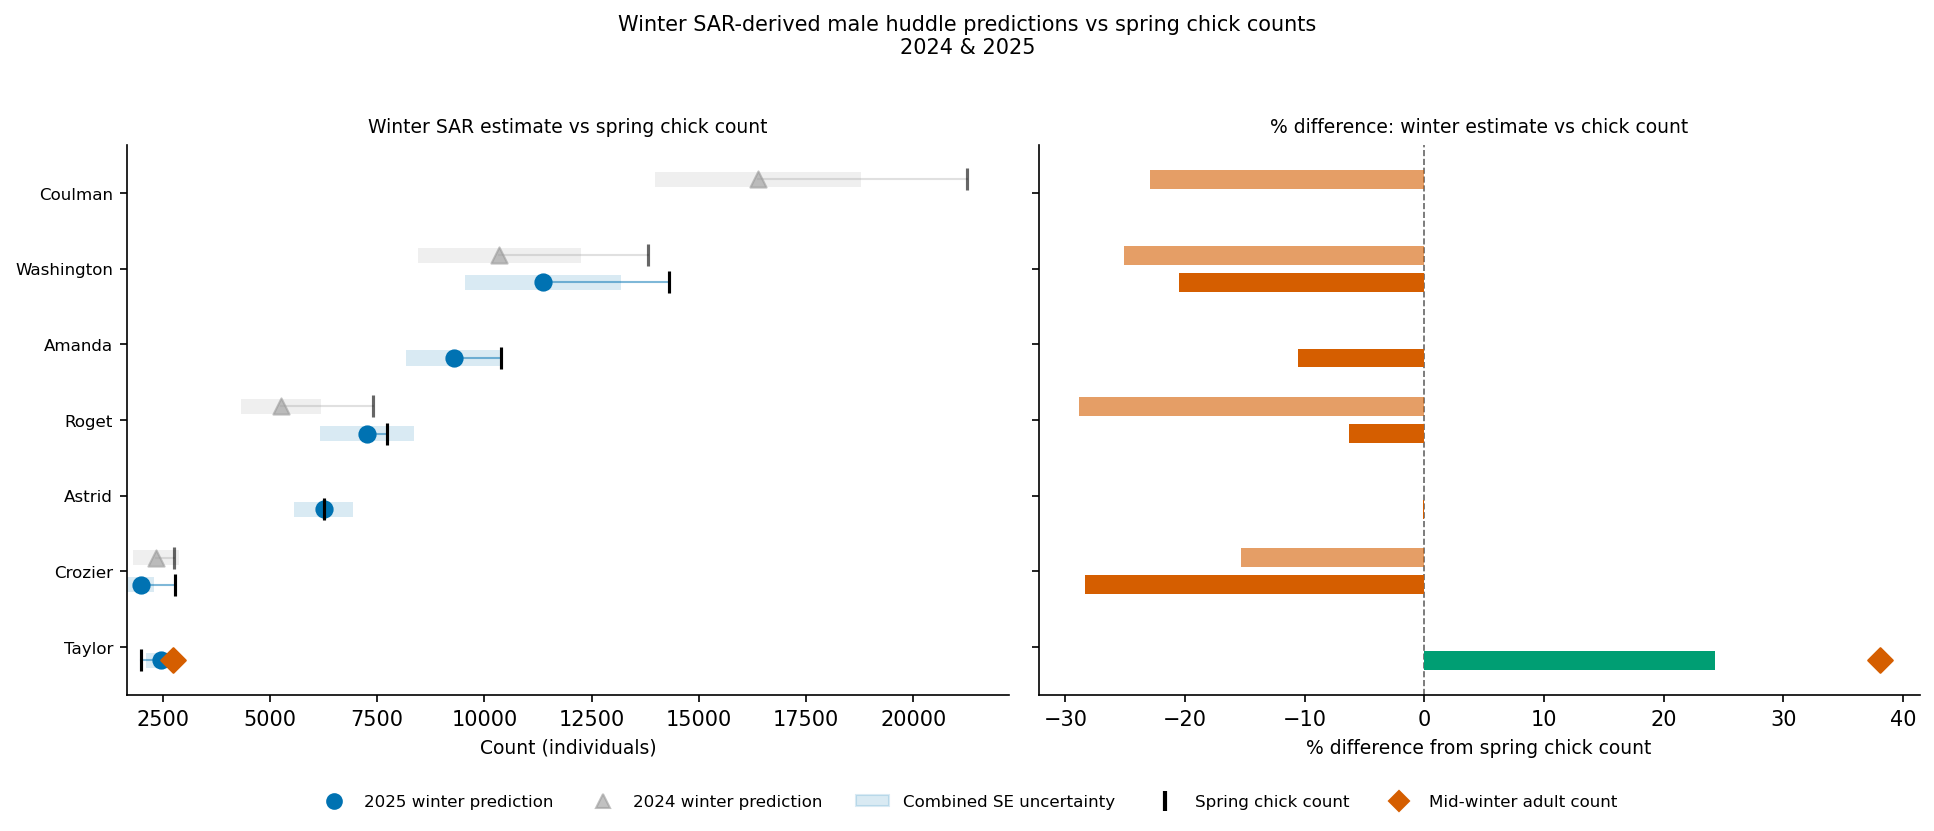


Winter vs spring chick count summary (2024 & 2025):
Colony                 Year    BP_winter      ±SE   chicks_obs   pct_diff flag
--------------------------------------------------------------------------------
Taylor                 2025        2,470      372        1,987      24.3%  low n
Crozier                2024        2,350      538        2,773     -15.3%  good
Crozier                2025        1,991      313        2,782     -28.4%  good
Astrid                 2025        6,253      682        6,258      -0.1%  low n
Roget                  2024        5,261      939        7,397     -28.9%  good
Roget                  2025        7,252    1,096        7,736      -6.3%  good
Amanda                 2025        9,282    1,111       10,387     -10.6%  low n
Washington             2024       10,341    1,897       13,803     -25.1%  good
Washington             2025       11,368    1,819       14,297     -20.5%  good
Coulman                2024       16,376    2,391       21,242  

In [13]:
# ── Build comparison using combined uncertainty export dataframes ───────────
chick_clean["year"] = chick_clean["year"].astype(int)

comparison_rows = []

for _, row in chick_clean.iterrows():
    colony     = row["colony_name"]
    chicks_obs = row["count_total"]
    chick_year = row["year"]

    # Select correct combined uncertainty export dataframe
    if chick_year == 2025:
        df_huddle = dfRFD
    else:
        df_huddle = dfMLR

    # Match colony
    match = df_huddle[df_huddle["colony_name"] == colony]

    if len(match) == 0:
        print(f"NO MATCH: colony={colony}, year={chick_year}")
        continue

    r_huddle = match.iloc[0]
    print(f"MATCHED: colony={colony}, year={chick_year}, "
          f"count_mean={r_huddle['count_mean']:.0f}, "
          f"combined_se={r_huddle['combined_se_pm']:.0f}")

    comparison_rows.append({
        "colony":         colony,
        "year":           chick_year,
        "BP_winter":      r_huddle["count_mean"],
        "BP_lower":       r_huddle["combined_lower"],
        "BP_upper":       r_huddle["combined_upper"],
        "combined_se_pm": r_huddle["combined_se_pm"],
        "coeff_se_pm":    r_huddle["coeff_se_pm"],
        "obs_sem":        r_huddle["obs_sem"],
        "n_obs":          r_huddle["n_obs"],
        "uncertainty_flag": r_huddle["uncertainty_flag"],
        "chicks_obs":     chicks_obs,
    })

dfComp = pd.DataFrame(comparison_rows).dropna(subset=["BP_winter"])
dfComp["pct_diff"] = ((dfComp["BP_winter"] - dfComp["chicks_obs"]) /
                       dfComp["chicks_obs"] * 100).round(1)

print(f"\nRows matched: {len(dfComp)}")
print(dfComp[["colony", "year", "BP_winter", "combined_se_pm",
              "chicks_obs", "pct_diff"]].to_string(index=False))

# Remove Coulman 2025 — chick count reduction due to iceberg mortality event
# not representative of model performance
dfComp = dfComp[~((dfComp["colony"] == "Coulman") & 
                   (dfComp["year"] == 2025))].copy()

print(f"Rows after removing Coulman 2025: {len(dfComp)}")


# Sort by 2025 chick count for consistent y ordering
colony_order = (
    dfComp[dfComp["year"] == 2025]
    .sort_values("chicks_obs")["colony"]
    .tolist()
)
for c in dfComp[dfComp["year"] == 2024]["colony"].unique():
    if c not in colony_order:
        colony_order.append(c)

y_positions = {colony: i for i, colony in enumerate(colony_order)}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

year_colors  = {2024: "#999999", 2025: "#0072B2"}
year_alphas  = {2024: 0.6,       2025: 1.0}
year_markers = {2024: "^",       2025: "o"}

for _, r in dfComp.iterrows():
    if r["colony"] not in y_positions:
        continue

    y      = y_positions[r["colony"]]
    y_off  = y + (0.18 if r["year"] == 2024 else -0.18)
    color  = year_colors[r["year"]]
    alpha  = year_alphas[r["year"]]
    marker = year_markers[r["year"]]

    # Left panel
    ax = axes[0]
    # Combined uncertainty bar
    ax.barh(y_off, r["BP_upper"] - r["BP_lower"],
            left=r["BP_lower"],
            height=0.2, color=color, alpha=0.15, zorder=2)
    ax.scatter(r["BP_winter"], y_off,
               color=color, marker=marker, s=60,
               alpha=alpha, zorder=4)
    ax.scatter(r["chicks_obs"], y_off,
               color="black", marker="|", s=120,
               alpha=alpha, zorder=5)
    ax.plot([r["BP_winter"], r["chicks_obs"]], [y_off, y_off],
            color=color, linewidth=1.0, alpha=alpha * 0.5, zorder=3)

    # Right panel
    bar_color = "#009E73" if r["pct_diff"] >= 0 else "#D55E00"
    axes[1].barh(y_off, r["pct_diff"],
                 height=0.25, color=bar_color,
                 alpha=alpha, zorder=3)

axes[0].set_xlabel("Count (individuals)", fontsize=9)
axes[0].set_title("Winter SAR estimate vs spring chick count", fontsize=9)

axes[1].set_xlabel("% difference from spring chick count"
                   , fontsize=9)
axes[1].set_title("% difference: winter estimate vs chick count", fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ── Taylor ground truth ────────────────────────────────────────────────────
taylor_winter_adults = 2743
if "Taylor" in y_positions:
    y_taylor     = y_positions["Taylor"]
    y_taylor_off = y_taylor - 0.18

    axes[0].scatter(taylor_winter_adults, y_taylor_off,
                    color="#D55E00", marker="D", s=70, zorder=5)
    taylor_chicks = chick_clean.loc[
        (chick_clean["colony_name"] == "Taylor") &
        (chick_clean["year"] == 2025), "count_total"
    ].values
    if len(taylor_chicks) > 0:
        pct = ((taylor_winter_adults - taylor_chicks[0]) / taylor_chicks[0]) * 100
        axes[1].scatter(pct, y_taylor_off,
                        color="#D55E00", marker="D", s=70, zorder=5)


# ── Y-axis labels last ─────────────────────────────────────────────────────
colony_labels = ["Coulman" if c == "Coulman" else c for c in colony_order]
for ax in axes:
    ax.set_yticks(range(len(colony_labels)))
    ax.set_yticklabels(colony_labels, fontsize=8)

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    plt.Line2D([0], [0], marker="o", color=year_colors[2025],
               linestyle="None", markersize=7, label="2025 winter prediction"),
    plt.Line2D([0], [0], marker="^", color=year_colors[2024],
               linestyle="None", markersize=7, alpha=0.6,
               label="2024 winter prediction"),
    plt.matplotlib.patches.Patch(color="#0072B2", alpha=0.15,
                                  label="Combined SE uncertainty"),
    plt.Line2D([0], [0], marker="|", color="black",
               linestyle="None", markersize=10, markeredgewidth=2,
               label="Spring chick count"),
    plt.Line2D([0], [0], marker="D", color="#D55E00",
               linestyle="None", markersize=7, label="Mid-winter adult count"),
]
fig.legend(handles=legend_elements, loc="lower center",
           bbox_to_anchor=(0.5, -0.06), ncol=5, fontsize=8, frameon=False)

fig.suptitle(
    "Winter SAR-derived male huddle predictions vs spring chick counts\n"
    "2024 & 2025",
    fontsize=10, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/winter_vs_chick_counts_2024-25_combined_se_NoCOUL25.png"),
            bbox_inches="tight", dpi=150)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print("\nWinter vs spring chick count summary (2024 & 2025):")
print(f"{'Colony':<20} {'Year':>6} {'BP_winter':>12} {'±SE':>8} "
      f"{'chicks_obs':>12} {'pct_diff':>10} {'flag'}")
print("-" * 80)
for _, r in dfComp.sort_values(["chicks_obs", "year"]).iterrows():
    print(f"{r['colony']:<20} {int(r['year']):>6} "
          f"{r['BP_winter']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['chicks_obs']:>12,.0f} "
          f"{r['pct_diff']:>9.1f}%  "
          f"{r['uncertainty_flag']}")

print(f"\n2025 mean % difference: "
      f"{dfComp[dfComp['year']==2025]['pct_diff'].mean():.1f}%")
print(f"2024 mean % difference: "
      f"{dfComp[dfComp['year']==2024]['pct_diff'].mean():.1f}%")
print(f"Overall mean % difference: {dfComp['pct_diff'].mean():.1f}%")



In [14]:
#Rerunning the stats without Coulman 2025

# ── Stats ──────────────────────────────────────────────────────────────────
from scipy import stats

print("\nNote: Coulman 2025 excluded from all performance statistics")
print(f"      (iceberg-induced chick mortality — n={len(dfComp)} pairs used)")


#Pearsons R 
r_val, p_val = stats.pearsonr(dfComp["BP_winter"], dfComp["chicks_obs"])

#Slope
slope, intercept, r_value, p_value, se = stats.linregress(
    dfComp["chicks_obs"], dfComp["BP_winter"]
)

#
mape = np.abs(dfComp["pct_diff"]).mean()
bias = dfComp["pct_diff"].mean()

print(f"\nModel performance statistics:")
print(f"  Pearson r:    {r_val:.3f}  (p={p_val:.4f})")
print(f"  R²:           {r_value**2:.3f}")
print(f"  Slope:        {slope:.3f}")
print(f"  MAPE:         {mape:.1f}%")
print(f"  Mean bias:    {bias:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")


Note: Coulman 2025 excluded from all performance statistics
      (iceberg-induced chick mortality — n=10 pairs used)

Model performance statistics:
  Pearson r:    0.989  (p=0.0000)
  R²:           0.978
  Slope:        0.745
  MAPE:         18.2%
  Mean bias:    -13.4%  (underestimate)


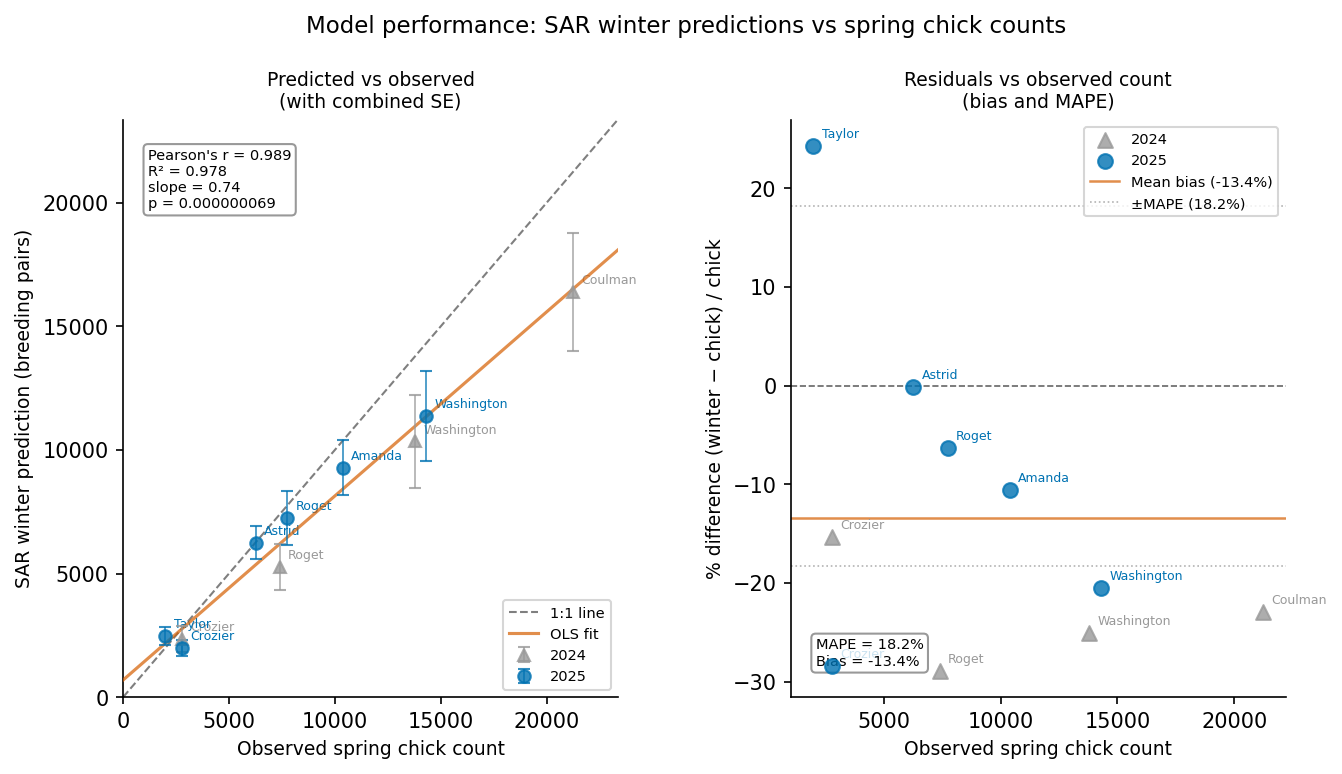


Model performance statistics (Coulman 2025 excluded):
  n pairs:       10
  Pearson r:     0.989  (p = 0.0000)
  R²:            0.978
  Slope:         0.745
  Intercept:     693
  MAPE:          18.2%
  Mean bias:     -13.4%  (underestimate)


In [18]:
from scipy import stats
import matplotlib.gridspec as gridspec

# ── Calculate stats on filtered dfComp (Coulman 2025 excluded) ────────────
slope, intercept, r_value, p_value, se = stats.linregress(
    dfComp["chicks_obs"], dfComp["BP_winter"]
)
r_val, p_val = stats.pearsonr(dfComp["BP_winter"], dfComp["chicks_obs"])
mape  = np.abs(dfComp["pct_diff"]).mean()
bias  = dfComp["pct_diff"].mean()

# ── Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

year_colors  = {2024: "#999999", 2025: "#0072B2"}
year_markers = {2024: "^",       2025: "o"}

# ── Panel 1 — scatter with 1:1 line and regression ────────────────────────
ax1 = fig.add_subplot(gs[0])

for yr in [2024, 2025]:
    mask = dfComp["year"] == yr
    ax1.errorbar(
        dfComp.loc[mask, "chicks_obs"],
        dfComp.loc[mask, "BP_winter"],
        yerr=dfComp.loc[mask, "combined_se_pm"],
        fmt=year_markers[yr],
        color=year_colors[yr],
        markersize=6,
        capsize=3,
        linewidth=0.8,
        alpha=0.8,
        label=str(yr),
        zorder=4
    )
    # Colony labels
    for _, r in dfComp[mask].iterrows():
        ax1.annotate(
            r["colony"],
            xy=(r["chicks_obs"], r["BP_winter"]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6, color=year_colors[yr]
        )

# 1:1 line
lim_max = max(dfComp["chicks_obs"].max(),
              dfComp["BP_winter"].max()) * 1.1
lim_min = 0
ax1.plot([lim_min, lim_max], [lim_min, lim_max],
         "k--", linewidth=1, alpha=0.5, label="1:1 line", zorder=2)

# Regression line
x_range = np.linspace(lim_min, lim_max, 100)
ax1.plot(x_range, slope * x_range + intercept,
         color="#D55E00", linewidth=1.5, linestyle="-",
         alpha=0.7, label="OLS fit", zorder=3)

# Stats annotation
ax1.text(0.05, 0.95,
         f"Pearson's r = {r_val:.3f}\nR² = {r_value**2:.3f}\n"
         f"slope = {slope:.2f}\np = {p_val:.9f}",
         transform=ax1.transAxes,
         fontsize=7, va="top", ha="left",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", alpha=0.8, edgecolor="grey"))

ax1.set_xlabel("Observed spring chick count", fontsize=9)
ax1.set_ylabel("SAR winter prediction (breeding pairs)", fontsize=9)
ax1.set_title("Predicted vs observed\n(with combined SE)", fontsize=9)
ax1.legend(fontsize=7, loc="lower right")
ax1.set_xlim(lim_min, lim_max)
ax1.set_ylim(lim_min, lim_max)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── Panel 2 — residuals (% difference) by colony ──────────────────────────
ax2 = fig.add_subplot(gs[1])

for yr in [2024, 2025]:
    mask = dfComp["year"] == yr
    ax2.scatter(
        dfComp.loc[mask, "chicks_obs"],
        dfComp.loc[mask, "pct_diff"],
        color=year_colors[yr],
        marker=year_markers[yr],
        s=50, alpha=0.8, zorder=4,
        label=str(yr)
    )
    for _, r in dfComp[mask].iterrows():
        ax2.annotate(
            r["colony"],
            xy=(r["chicks_obs"], r["pct_diff"]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6, color=year_colors[yr]
        )

ax2.axhline(0,    color="black",  linewidth=0.8, linestyle="--", alpha=0.6)
ax2.axhline(bias, color="#D55E00", linewidth=1.2, linestyle="-",
            alpha=0.7, label=f"Mean bias ({bias:.1f}%)")

# ±MAPE lines
ax2.axhline( mape, color="grey", linewidth=0.8, linestyle=":",
             alpha=0.6, label=f"±MAPE ({mape:.1f}%)")
ax2.axhline(-mape, color="grey", linewidth=0.8, linestyle=":", alpha=0.6)

ax2.set_xlabel("Observed spring chick count", fontsize=9)
ax2.set_ylabel("% difference (winter − chick) / chick", fontsize=9)
ax2.set_title("Residuals vs observed count\n(bias and MAPE)", fontsize=9)
ax2.legend(fontsize=7, loc="upper right")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Stats annotation
ax2.text(0.05, 0.05,
         f"MAPE = {mape:.1f}%\nBias = {bias:.1f}%",
         transform=ax2.transAxes,
         fontsize=7, va="bottom", ha="left",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", alpha=0.8, edgecolor="grey"))

fig.suptitle(
    "Model performance: SAR winter predictions vs spring chick counts"
    , fontsize=11, y=1.02
)

plt.savefig(os.path.join(INPUTPATH,
            "Final results/fig_model_performance_stats.png"),
            bbox_inches="tight", dpi=200)
plt.show()

# ── Print full stats summary ───────────────────────────────────────────────
print("\nModel performance statistics (Coulman 2025 excluded):")
print(f"  n pairs:       {len(dfComp)}")
print(f"  Pearson r:     {r_val:.3f}  (p = {p_val:.4f})")
print(f"  R²:            {r_value**2:.3f}")
print(f"  Slope:         {slope:.3f}")
print(f"  Intercept:     {intercept:.0f}")
print(f"  MAPE:          {mape:.1f}%")
print(f"  Mean bias:     {bias:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")

The panels show:  
- Panel 1 — Predicted vs observed scatter with 1:1 line, regression line, error bars from combined SE, and key stats annotated. Points above the 1:1 line are overestimates, below are underestimates.
- Panel 2 — Residuals plot showing percentage difference against observed count. The orange line is mean bias, grey dotted lines are ±MAPE. Reveals whether errors are random or structured, if larger colonies consistently have bigger errors that suggests a scaling problem.

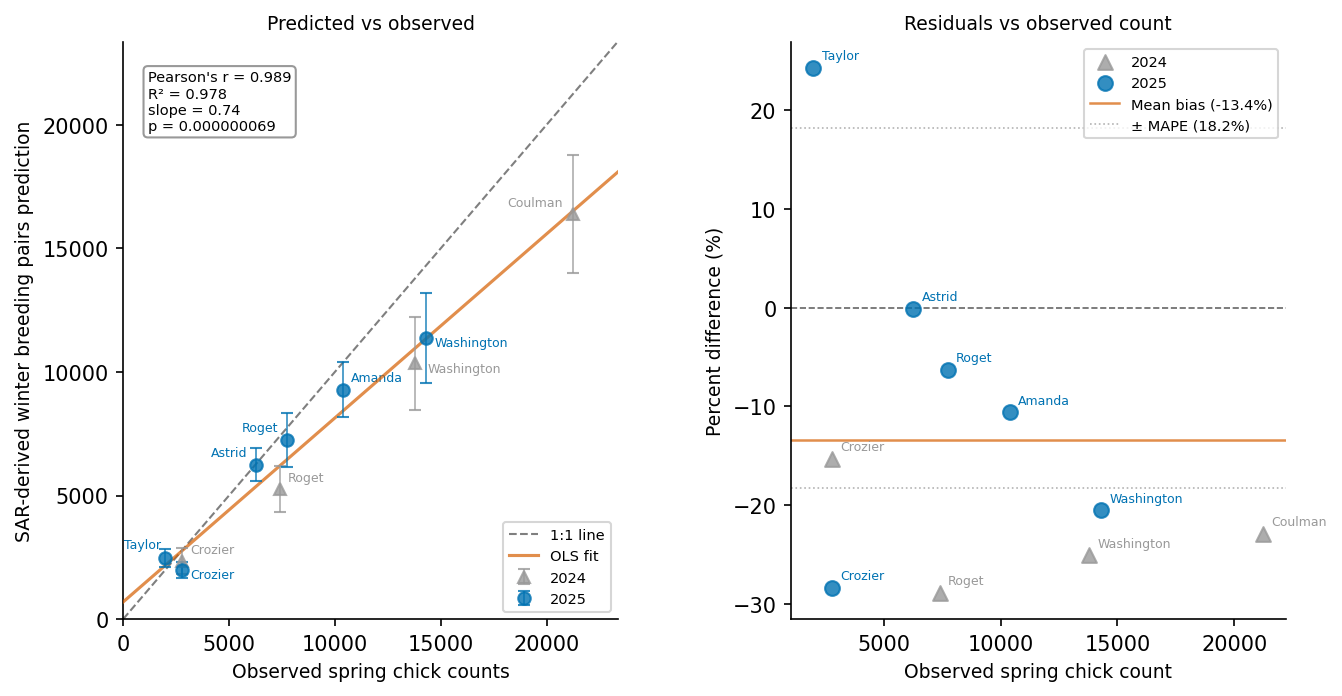


Model performance statistics (Coulman 2025 excluded):
  n pairs:       10
  Pearson r:     0.989  (p = 0.0000)
  R²:            0.978
  Slope:         0.745
  Intercept:     693
  MAPE:          18.2%
  Mean bias:     -13.4%  (underestimate)


In [19]:
from scipy import stats
import matplotlib.gridspec as gridspec

# ── Calculate stats on filtered dfComp (Coulman 2025 excluded) ────────────
slope, intercept, r_value, p_value, se = stats.linregress(
    dfComp["chicks_obs"], dfComp["BP_winter"]
)
r_val, p_val = stats.pearsonr(dfComp["BP_winter"], dfComp["chicks_obs"])
mape  = np.abs(dfComp["pct_diff"]).mean()
bias  = dfComp["pct_diff"].mean()

# ── Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

year_colors  = {2024: "#999999", 2025: "#0072B2"}
year_markers = {2024: "^",       2025: "o"}

# ── Panel 1 — scatter with 1:1 line and regression ────────────────────────
ax1 = fig.add_subplot(gs[0])
# Custom label offsets per colony to prevent overlap
# Year-specific label offsets — colony name + year as key
label_offsets_yr = {
    ("Taylor",     2025): (-2, 5), 
    ("Roget",      2024): (4, 4),   
    ("Roget",      2025): (-4, 4),   
    ("Washington", 2024): (6, -4),  
    ("Washington", 2025): (4, -4),  
    ("Crozier",    2024): (4, 4),    
    ("Crozier",    2025): (4, -4),    
    ("Coulman",    2024): (-5, 4),   
    ("Astrid",     2025): (-4, 4),   
}

for yr in [2024, 2025]:
    mask = dfComp["year"] == yr
    ax1.errorbar(
        dfComp.loc[mask, "chicks_obs"],
        dfComp.loc[mask, "BP_winter"],
        yerr=dfComp.loc[mask, "combined_se_pm"],
        fmt=year_markers[yr],
        color=year_colors[yr],
        markersize=6,
        capsize=3,
        linewidth=0.8,
        alpha=0.8,
        label=str(yr),
        zorder=4
    )
    default_offset = (-40, 4) if yr == 2024 else (4, 4)
    for _, r in dfComp[mask].iterrows():
        # Check year-specific override first, then fall back to default
        offset = label_offsets_yr.get(
            (r["colony"], yr),
            default_offset
        )
        ax1.annotate(
            r["colony"],
            xy=(r["chicks_obs"], r["BP_winter"]),
            xytext=offset,
            textcoords="offset points",
            fontsize=6,
            color=year_colors[yr],
            ha="right" if offset[0] < 0 else "left"
        )

# 1:1 line
lim_max = max(dfComp["chicks_obs"].max(),
              dfComp["BP_winter"].max()) * 1.1
lim_min = 0
ax1.plot([lim_min, lim_max], [lim_min, lim_max],
         "k--", linewidth=1, alpha=0.5, label="1:1 line", zorder=2)

# Regression line
x_range = np.linspace(lim_min, lim_max, 100)
ax1.plot(x_range, slope * x_range + intercept,
         color="#D55E00", linewidth=1.5, linestyle="-",
         alpha=0.7, label="OLS fit", zorder=3)

# Stats annotation
ax1.text(0.05, 0.95,
         f"Pearson's r = {r_val:.3f}\nR² = {r_value**2:.3f}\n"
         f"slope = {slope:.2f}\np = {p_val:.9f}", #Here is where we add p-value 0s, refine this
         transform=ax1.transAxes,
         fontsize=7, va="top", ha="left",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white", alpha=0.8, edgecolor="grey"))

ax1.set_xlabel("Observed spring chick counts", fontsize=9)
ax1.set_ylabel("SAR-derived winter breeding pairs prediction", fontsize=9)
ax1.set_title("Predicted vs observed", fontsize=9)
ax1.legend(fontsize=7, loc="lower right")
ax1.set_xlim(lim_min, lim_max)
ax1.set_ylim(lim_min, lim_max)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── Panel 2 — residuals (% difference) by colony ──────────────────────────
ax2 = fig.add_subplot(gs[1])

for yr in [2024, 2025]:
    mask = dfComp["year"] == yr
    ax2.scatter(
        dfComp.loc[mask, "chicks_obs"],
        dfComp.loc[mask, "pct_diff"],
        color=year_colors[yr],
        marker=year_markers[yr],
        s=50, alpha=0.8, zorder=4,
        label=str(yr)
    )
    for _, r in dfComp[mask].iterrows():
        ax2.annotate(
            r["colony"],
            xy=(r["chicks_obs"], r["pct_diff"]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6, color=year_colors[yr]
        )

ax2.axhline(0,    color="black",  linewidth=0.8, linestyle="--", alpha=0.6)
ax2.axhline(bias, color="#D55E00", linewidth=1.2, linestyle="-",
            alpha=0.7, label=f"Mean bias ({bias:.1f}%)")
ax2.axhline( mape, color="grey", linewidth=0.8, linestyle=":",
             alpha=0.6, label=f"± MAPE ({mape:.1f}%)")
ax2.axhline(-mape, color="grey", linewidth=0.8, linestyle=":", alpha=0.6)

ax2.set_xlabel("Observed spring chick count", fontsize=9)
ax2.set_ylabel("Percent difference (%)", fontsize=9)
ax2.set_title("Residuals vs observed count", fontsize=9)
ax2.legend(fontsize=7, loc="upper right")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.savefig(os.path.join(INPUTPATH,
            "Final results/fig_model_performance_stats.png"),
            bbox_inches="tight", dpi=200)
plt.show()

# ── Print full stats summary ───────────────────────────────────────────────
print("\nModel performance statistics (Coulman 2025 excluded):")
print(f"  n pairs:       {len(dfComp)}")
print(f"  Pearson r:     {r_val:.3f}  (p = {p_val:.4f})")
print(f"  R²:            {r_value**2:.3f}")
print(f"  Slope:         {slope:.3f}")
print(f"  Intercept:     {intercept:.0f}")
print(f"  MAPE:          {mape:.1f}%")
print(f"  Mean bias:     {bias:.1f}%  "
      f"({'overestimate' if bias > 0 else 'underestimate'})")